## Black-Scholes Equation

The Black-Scholes theorem assume that the stock price follows a geometric Brownian motion, given by,
\begin{align}
dS = \mu S dt + \sigma S dz
\end{align}
where $\mu$ and $\sigma$ are the mean growth rate and volatility, respectively, and $dz$ is the Wiener process. Let's $F(S,t)$ be the price of a derivative on the stock at time $t$ and for stock price $S$. Then according to Ito lemma, derivative price then changes as,
\begin{align*}
dF = \left[\frac{\partial F}{\partial t}+ \mu S\frac{\partial F}{\partial S} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2}\right]dt + \sigma S\frac{\partial F}{\partial S} dz
\end{align*}
We can see that the derivative is also a stochastic process with same underlying Wiener process. We can then show that the *risk-neutral* price of the derivative can be obtained by assuming that the stock and the derivative both grows at the risk-free interest rate $r$, i.e.
\begin{align*}
\frac{\partial F}{\partial t}+ r S\frac{\partial F}{\partial S} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2} = rF
\end{align*}
where we have replaced $\mu$ with $r$ and equated the $dt$ coefficient of the $dF$ with the $rF$. This is the **Black-Scholes differential equation**.

The equation can be obtained by creating a self-financing portfolio, using cash-account and stock, which reproduces the payoff of the derivative. Let the portfolio, at time $t$, consist of $x(t)$ amount in cash and $y(t)$ amount of stock. The value of this portfolio is given by,
\begin{align*}
P(t) = x(t) B(t) + y(t)S(t)
\end{align*}
where $B(t)=e^{rt}$ tracks the change in cash-account due to the interest rate. The change in the value of the portfolio is given by,
\begin{align*}
dP(t) = dx(t) B(t) + x(t) dB(t) + dy(t)S(t) + y(t)dS(t).
\end{align*}
Since this portfolio is self-financing, i.e. the changes in value is only due to change in stock-price and interest-rates, not because we inject to or withdraw from funds externally, we must have $ dx(t) B(t) = -dy(t)S(t)$ (funds are simply rearranged between stock and cash-account).
\begin{align*}
dP(t) &= x(t) dB(t) + y(t)dS(t) \\
dP(t) &= x(t) r B(t) dt + y(t)[\mu S dt + \sigma S dz] \\
\end{align*}
Here we have used the fact that the $B(t)$ grews exponentially at the risk-free interest rate and that stock-price follows geometric Brownian motion.

Since the portfolio should be replicating the derivative price, we require, 
\begin{align*}
\frac{\partial F}{\partial t}+ \mu S\frac{\partial F}{\partial S} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2}  &= x(t) r B(t)  + y(t)\mu S  \\
\sigma S\frac{\partial F}{\partial S}  &= y(t) \sigma S \\
\end{align*}
Here we have equated the deterministic and stochastic parts of $dF$ and $dP$. From using the results from the second equation, ${\partial F}/{\partial S}  = y(t)$ from above, in the first one, we arrive at
\begin{align*}
\frac{\partial F}{\partial t}+ \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2}  &= r x(t) B(t) = r\left[F-S(t) \frac{\partial F}{\partial S} \right]\\
\end{align*}
where we have used $P(t)=F(t)$. The above equation is simple the Black-Scholes equation.

The fact that $\mu$ does not play a role in the price of the system is simple a consequence of the risk-neutral pricing strategy. The price at time $t$ and stock price $S$ can be found by solving the Black-Scholes equation. The price at the maturity of the derivative is simply the payoff, for example $F(S,T)= \max (S-K,0)$ for call options, with maturity $T$ and strike $K$. This is the boundary condition to be applied while solving the equation.

# Dividend paying stock

The Black-Scholes equation is modified if the stock pays dividend. For a dividend rate $c$ that is assumed to paid continually, the self-financing portfolio value changes as,
\begin{align*}
dP(t) =  x(t) dB(t)+ y(t)[\tilde \mu S dt + \sigma S dz] +  y(t)cSdt.
\end{align*}
The last term is the dividend payment. We also used $\tilde\mu = \mu-c$ to indicate that the stock-price reduces as the dividend is payed (just for the sake of consistency). For replicating the derivative value, we need,
\begin{align*}
\frac{\partial F}{\partial t} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2} + (r-c)S \frac{\partial F}{\partial S}  = rF
\end{align*}


## Finite-difference method for solving Black-Scholes equations

In this work, we use finite differences method to numerically find solution to the Black-Scholes equation for European call and put options. In finite-differences, we look at the discretized version of the differential equation, which is solved algebraically. The discretized version of the derivatives are given as,
\begin{align*}
\partial_t F(S_i,t_j) &\approx \frac{F(S_{i},t_{j+1})-F(S_{i},t_j)}{\Delta t} \\
\partial_S F(S_i,t_j) &\approx \frac{F(S_{i+1},t_j)-F(S_{i},t_j)}{\Delta S}  \\
\partial_{S,S} F(S_i,t_j) &\approx \frac{F(S_{i+1},t_j)-2F(S_{i},t_j)+F(S_{i-1},t_j)}{\Delta S^2} 
\end{align*}

From the Black-Scholes equation, we have,
\begin{align*}
\partial_t F(S_i,t_j) = rF - (r-c) S\partial_S F(S_i,t_j) - \frac{1}{2}\sigma^2 S^2  \partial_{S,S} F(S_i,t_j)
\end{align*}
From the approximated form provided above, we can write,
\begin{align*}
F(S_{i},t_{j-1}) =  F(S_{i},t_{j}) - \Delta t \left[rF(S_i,t_j) - (r-c) S\partial_S F(S_i,t_j) - \frac{1}{2}\sigma^2 S^2  \partial_{S,S} F(S_i,t_j)\right]
\end{align*}
Since the boundary conditions are known at $t=T$, the price is solved backwards in time iteratively. 

### Analytical price of options

The Black-Scholes theorem assumes that the stock price follows a geometric brownian motion. The fair price of a european call option on the stock at time $t$ is given by,
$$C(S,t) = S\Phi(d_1) -K\Phi(d_2)\exp[-r(T-t)],$$
where $S$ is the stock price at $t$, $K$ is the strike price, and $T$ is the expiration time. We also have the risk-free interest rate $r$, 
$$ d_1=\frac{\log(S/K)+(r+\sigma^2/2)(T-t)}{\sigma\sqrt{T-t}},$$
and 
$$d_2 = d_1-\sigma\sqrt{T-t}$$
Here, $\sigma$ is the volatility of the stock price

The put price $ P(S,t) $ can be obtained from the call price using put-call parity of european options
$$ C(S,t) + K \exp[-r(T-t)] = P(S,t) + S_t $$



In [ ]:
# Packages

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm #Normal PDF and CDF
from numpy.random import normal # normal random variable

## European option

In [ ]:
# European option
class EuropeanOption:

    # Option parameters
    def __init__(self, K, T, r, c, sigma,Opt_type):
        if Opt_type not in ["call", "put"]:
            raise ValueError( "Opt_type must be 'call' or 'put'" )
        self.Opt_type = Opt_type
        self.K  = K 
        self.T  = T 
        self.r  = r
        self.sigma = sigma 
        self.c =  c

    # Price using finite-difference method
    def priceFD(self,Smax,dS,dt,sigma=None):
    
        sigma = self.sigma if sigma is None else sigma

        # Defining grids
        S_grid = np.arange(0, Smax+dS, dS) # stock price
        t_grid = np.arange(0,self.T+dt,dt) # time array for storing

        # Number of points
        nS, nt = len(S_grid), len(t_grid)

        # Stores option price at various t and S
        F_grid = np.zeros([nt,nS]) #Output array

        # Boundary Values (at t=T)
        if self.Opt_type == "call":
            F_grid[-1] =  np.maximum(0,S_grid-self.K)
        else:
            F_grid[-1] = np.maximum(0,self.K-S_grid) 
        
        #pre-calculating constants 
        G1_const = 0.5*(sigma*S_grid[1:-1])**2
        G2_const = (self.r-self.c)*S_grid[1:-1]

        # Calculating price backwards in time
        for i in range(1,nt):

            dF_grid = (F_grid[nt-i,2:]-F_grid[nt-i,:-2])/(2*dS)
            ddF_grid = (F_grid[nt-i,2:]- 2* F_grid[nt-i,1:-1] + F_grid[nt-i,:-2]) /(dS*dS)
            
            # Finite difference sequence: vector form
            G1 = ddF_grid*G1_const
            G2 = dF_grid*G2_const
            G3 = self.r*F_grid[nt-i,1:-1]
            F_grid[nt-i-1,1:-1] = F_grid[nt-i,1:-1] + dt* (G1+G2-G3)

            # Values at large S and S=0
            if self.Opt_type == "call":
                F_grid[nt-i-1,0],F_grid[nt-i-1,-1] = 0.0, Smax*np.exp(-self.c*i*dt)-self.K*np.exp(-self.r*i*dt)
            else:
                F_grid[nt-i-1,0],F_grid[nt-i-1,-1] = self.K*np.exp(-self.r*i*dt), 0.0

        return S_grid, t_grid , F_grid
    
    # Analytical price of option
    def priceExact(self,Smax,dS,t):
        
        S_grid = np.arange(0, Smax+dS, dS) # stock price

        t_period = self.T-t # Time to maturity
        d1 = self._d1Param_(S_grid,t_period)
        d2 = d1-(self.sigma*np.sqrt(t_period))
        if self.Opt_type == "call":
            return S_grid, np.exp(-self.c*t_period)*S_grid*norm.cdf(d1) - np.exp(-self.r*t_period)*self.K*norm.cdf(d2)
        else:
            return S_grid,-np.exp(-self.c*t_period)*S_grid*norm.cdf(-d1) + np.exp(-self.r*t_period)*self.K*norm.cdf(-d2)
    
    # Delta using finite-difference method
    def DeltaFD(self,Smax,dS,dt):
        S_grid, t_grid , F_grid = self.priceFD(Smax,dS,dt)
        delta_grid = (F_grid[:,2:]-F_grid[:,:-2])/(2*dS)
        return S_grid[1:-1], t_grid, delta_grid
    
    # Theta using finite-difference method
    def ThetaFD(self,Smax,dS,dt):
        S_grid, t_grid , F_grid = self.priceFD(Smax,dS,dt)
        theta_grid = (F_grid[2:]-F_grid[:-2])/(2*dt)
        return S_grid, t_grid[1:-1], theta_grid
    
    # Gamma using finite-difference method
    def GammaFD(self,Smax,dS,dt):
        SD_grid, t_grid , deltaGrid = self.DeltaFD(Smax,dS,dt)
        gamma_grid = (deltaGrid[:,2:]-deltaGrid[:,:-2])/(2*dS)
        return SD_grid[1:-1], t_grid, gamma_grid
    
    # Vega using finite-difference method
    def VegaFD(self,Smax,dS,dt,dsig):
        SigP, SigM = self.sigma+0.5*dsig,self.sigma-0.5*dsig
        S_grid, t_grid , F_gridP = self.priceFD(Smax,dS,dt,sigma=SigP)
        S_grid, t_grid , F_gridM = self.priceFD(Smax,dS,dt,sigma=SigM)
        vega_grid = (F_gridP-F_gridM)/dsig
        return S_grid, t_grid, vega_grid
    
    # Delta from exact formula
    def DeltaExact(self,Smax,dS,t):
        S_grid = np.arange(0, Smax+dS, dS) # stock price
        t_period = self.T-t # Time to maturity
        d1 = self._d1Param_(S_grid,t_period)
        if self.Opt_type == "call":
            return S_grid, np.exp(-self.c*t_period)*norm.cdf(d1)
        else:
            return S_grid, np.exp(-self.c*t_period)*(norm.cdf(d1)-1.0)
        
    # Gamma from exact formula
    def GammaExact(self,Smax,dS,t):
        S_grid = np.arange(dS, Smax+dS, dS) # stock price
        t_period = self.T-t # Time to maturity
        d1 = self._d1Param_(S_grid,t_period)
        return S_grid, np.exp(-self.c*t_period)*norm.pdf(d1)/ (S_grid*self.sigma*np.sqrt(t_period))
        
        
    # Theta from exact formula
    def ThetaExact(self,Smax,dS,t):
        S_grid = np.arange(0, Smax+dS, dS) # stock price
        t_period = self.T-t # Time to maturity
        
        d1 = self._d1Param_(S_grid,t_period)
        d2 = d1-(self.sigma*np.sqrt(t_period))
        term1 = 0.5*np.exp(-self.c*t_period)*(S_grid*norm.pdf(d1)*self.sigma)/np.sqrt(t_period)
        if self.Opt_type == "call":
            term2 = self.c*np.exp(-self.c*t_period)*S_grid*norm.cdf(d1)
            term3 = self.r*self.K*np.exp(-self.r*t_period)*norm.cdf(d2)
            return S_grid, -term1+term2-term3
        else:
            term2 = self.c*np.exp(-self.c*t_period)*S_grid*norm.cdf(-d1)
            term3 = self.r*self.K*np.exp(-self.r*t_period)*norm.cdf(-d2)
            return S_grid, -term1-term2+term3
        
    # Gamma from exact formula
    def VegaExact(self,Smax,dS,t):
        S_grid = np.arange(0, Smax+dS, dS) # stock price
        t_period = self.T-t # Time to maturity
        d1 = self._d1Param_(S_grid,t_period)
        return S_grid, S_grid*np.exp(-self.c*t_period)*norm.pdf(d1)*np.sqrt(t_period)
        

    def _d1Param_(self,S_grid,t_period):
        return (np.log(S_grid/self.K)+(self.r-self.c+0.5*self.sigma**2)*t_period)/(self.sigma*np.sqrt(t_period))



### Comparing the results for finite-difference and analytical prices

In [ ]:

# -----------------------
# Parameters
# Option parameters
r = 0.07 #interest rate
K = 100 # strike
sigma = 0.4 # volatility
c = 0.01 # dividend yield
T = 1 # Expiry time (years)

# Grid parameters
Smax = 500 # Max stock price
dS =  5 # grid size (stock price grio)
dt = 0.0002 # grid size (time grid)

# Defining the options
Option_EurCall = EuropeanOption(K, T, r, c, sigma,"call") 
Option_EurPut = EuropeanOption(K, T, r, c, sigma,"put") 

#--------------------------------------------
# Price obtained used finite-difference method
S_grid, tgrid, Price_grid_call = Option_EurCall.priceFD(Smax,dS,dt)
S_grid, tgrid, Price_grid_put = Option_EurPut.priceFD(Smax,dS,dt)

# Exact/analytical prices
S_grid, Price_grid_exc_call = Option_EurCall.priceExact(Smax,dS,0)
S_grid, Price_grid_exc_put = Option_EurPut.priceExact(Smax,dS,0)

# Plotting the option prices
fig, ax = plt.subplots(1,2, figsize=(10, 4))

ax[0].set_title("Call option")
ax[0].plot(S_grid,Price_grid_call[-1], label="t=T")
ax[0].plot(S_grid,Price_grid_call[0], label="t=0")
#ax[0].plot(S_grid,ff, label="t=0")
ax[0].plot(S_grid,Price_grid_exc_call, '--', label="Exact")
ax[0].set_xlim(0,500)
#ax[0].set_ylim(0,120)
ax[0].set_xlabel("Stock Price")
ax[0].set_ylabel("Option Price")
ax[0].legend()

ax[1].set_title("Put option")
ax[1].plot(S_grid,Price_grid_put[-1], label="t=T")
ax[1].plot(S_grid,Price_grid_put[0], label="t=0")
ax[1].plot(S_grid,Price_grid_exc_put, '--', label="Exact")
ax[1].set_xlim(0,500)
ax[1].set_xlabel("Stock Price")
ax[1].set_ylabel("Option Price")
ax[1].legend()

/var/folders/53/85zwmkmn6dv27k0hq0vkmqh80000gn/T/ipykernel_15498/244958229.py:143: RuntimeWarning: divide by zero encountered in log
  return (np.log(S_grid/self.K)+(self.r-self.c+0.5*self.sigma**2)*t_period)/(self.sigma*np.sqrt(t_period))


(5001, 99)


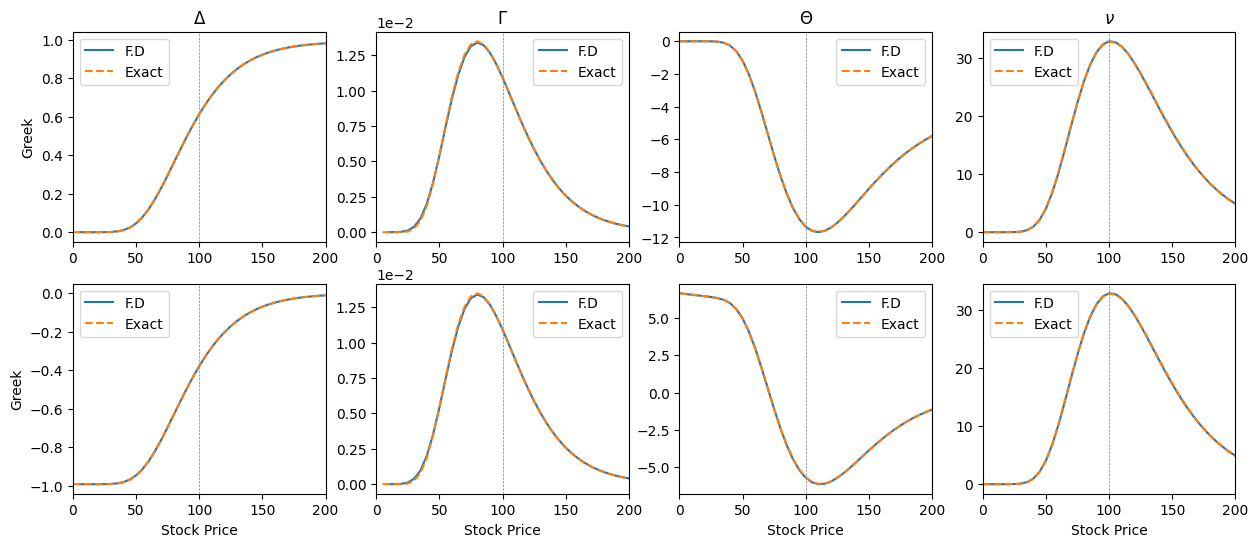

In [282]:
# 
Tau = 0.25*T # time
nTau = int(Tau/dt) # index (approx)

# Delta
SD_grid, tgrid, EurCall_delt = Option_EurCall.DeltaFD(Smax,dS,dt)
SD_grid, tgrid, EurPut_delt = Option_EurPut.DeltaFD(Smax,dS,dt)

S_grid, EurCall_Exc_delt = Option_EurCall.DeltaExact(Smax,dS,Tau)
S_grid, EurPut_Exc_delt = Option_EurPut.DeltaExact(Smax,dS,Tau)

# theta
SG_grid, tgrid, EurCall_gamm = Option_EurCall.GammaFD(Smax,dS,dt)
SG_grid, tgrid, EurPut_gamm = Option_EurPut.GammaFD(Smax,dS,dt)

SGx_grid, EurCall_Exc_gamm = Option_EurCall.GammaExact(Smax,dS,Tau)
SGx_grid, EurPut_Exc_gamm = Option_EurPut.GammaExact(Smax,dS,Tau)

#theta
S_grid, tgrid, EurCall_thet = Option_EurCall.ThetaFD(Smax,dS,dt)
S_grid, tgrid, EurPut_thet = Option_EurPut.ThetaFD(Smax,dS,dt)

S_grid, EurCall_Exc_thet = Option_EurCall.ThetaExact(Smax,dS,Tau)
S_grid, EurPut_Exc_thet = Option_EurPut.ThetaExact(Smax,dS,Tau)

#vega
S_grid, thgrid, EurCall_Veg = Option_EurCall.VegaFD(Smax,dS,dt,dsig=0.1)
S_grid, thgrid, EurPut_Veg = Option_EurPut.VegaFD(Smax,dS,dt,dsig=0.1)

S_grid, EurCall_Exc_Veg = Option_EurCall.VegaExact(Smax,dS,Tau)
S_grid, EurPut_Exc_Veg = Option_EurPut.VegaExact(Smax,dS,Tau)

print(EurPut_delt.shape)
# Plotting the delta
fig, ax = plt.subplots(2,4, figsize=(15, 6))


# Call option plots
ax[0,0].set_title("$\Delta$")
ax[0,0].plot(SD_grid,EurCall_delt[nTau], label="F.D")
ax[0,0].plot(S_grid,EurCall_Exc_delt, '--' ,label="Exact")

ax[0,1].set_title("$\Gamma$")
ax[0,1].plot(SG_grid,EurCall_gamm[nTau], label="F.D")
ax[0,1].plot(SGx_grid,EurCall_Exc_gamm, '--' ,label="Exact")

ax[0,2].set_title("$\Theta$")
ax[0,2].plot(S_grid,EurCall_thet[nTau], label="F.D")
ax[0,2].plot(S_grid,EurCall_Exc_thet, '--' ,label="Exact")

ax[0,3].set_title(r"$\nu$")
ax[0,3].plot(S_grid,EurCall_Veg[nTau], label="F.D")
ax[0,3].plot(S_grid,EurCall_Exc_Veg, '--' ,label="Exact")

#ax[1,0].set_title("Put option")

# Put option plots
ax[1,0].plot(SD_grid,EurPut_delt[nTau], label="F.D")
ax[1,0].plot(S_grid,EurPut_Exc_delt, '--' ,label="Exact")

ax[1,1].plot(SG_grid,EurPut_gamm[nTau], label="F.D")
ax[1,1].plot(SGx_grid,EurPut_Exc_gamm, '--' ,label="Exact")

ax[1,2].plot(S_grid,EurPut_thet[nTau], label="F.D")
ax[1,2].plot(S_grid,EurPut_Exc_thet, '--' ,label="Exact")

ax[1,3].plot(S_grid,EurPut_Veg[nTau], label="F.D")
ax[1,3].plot(S_grid,EurPut_Exc_Veg, '--' ,label="Exact")

for i in range(2):
    ax[i,0].set_ylabel("Greek")
    ax[i,1].ticklabel_format(axis='y', style='sci', scilimits=(0,4))
    for j in range(4):
        ax[i,j].set_xlim(0,200)
        ax[i,j].axvline(x=K, color='grey', linestyle='--', linewidth=0.5)

        ax[1,j].set_xlabel("Stock Price")
        #ax[1,0].set_ylabel("$\Theta(S,t=0)$")
        ax[i,j].legend()

# Barrier options 

Barrier options are exotic options that depends not only on the final value of the stock price at maturity, but also the path taken by it during option's lifetime. Here, whether the option payoff happens or not depends additionally on whether the stock price has crossed a certain value (the barrier) during its life time. If the conditions for the option payoff has been met, then the payoff is carried out similar to the European options. Due to this additional constrain, the price of barrier options are always less than the european options. 

There are broadly two types of barrier options, the "in" options and the "out" options. For the "in" options, the payout is carried out only if the stock price crosses the barrier. On the other hand, the "out" option becomes invalid if the stock price crosses the barrier. These options can be further divided into "up" and "down", depending on the initial stock price.

- Up and in: Barrier is higher than initial stock price, and stock must rise above the barrier for option to become payable
- Down and in: Barrier is lower than initial stock price, and stock must decrease below the barrier for option to become payable
- Up and out: Barrier is higher than initial stock price, and if stock rise above the barrier, option become invalid
- Down and out: Barrier is lower than initial stock price, and if stock decrease below the barrier, option become invalid

### Solving for the price of Barrier options

The "out" Barrier options can be solved similar to the the european options, with the added constrain that if $S>B$ (Up and out) or $S<B$ (down and out) , where $B$ is the barrier, the option price becomes zero. There entire option is only valid as long as it stays within Barrier. 

For the "in" barrier options, the situation is more complicated as the option may become valid for all values of "S". We therefore uses the parity relation between up and down options given by,
$$ P_{out}+P_{in} = P_{eur}$$
where $P_{out}$, $P_{in}$, and $P_{eur}$ are the prices of -up, -down, and the european options with the same strike price. For example, the holder of an up and out and up and in options get payout whether stock price crosses the barrier or not, the sum of its prices must be equal to of a european option. 


In [ ]:
# Defining the class for up/down and out options
class BarrierOutOption:
    # Option parameters
    def __init__(self, K, T, r, c, B, sigma,Opt_type):
        if Opt_type not in ["call", "put"]:
            raise ValueError( "Opt_type must be 'call' or 'put'" )
        #if Opt_direc not in ["up", "down"]:
        #    raise ValueError( "Opt_direc must be 'up' or 'down'")
        
        self.Opt_type = Opt_type
        self.K  = K 
        self.T  = T 
        self.r  = r
        self.sigma = sigma 
        self.c =  c
        self.B =  B

    # Pricing using finite-difference
    def priceFD_out(self,Opt_direc,Smax,dS,dt):

        if Opt_direc not in ["up", "down"]:
            raise ValueError( "Opt_direc must be 'up' or 'down'")
        
        if Opt_direc == "up": 
            S_grid = np.arange(0,self.B+dS,dS) # The array for stock goes from 0 to B, since F=0 at S>B 
        else:
            S_grid = np.arange(self.B,Smax+dS,dS)  # The array for stock goes from B+dS to S_max ,since F=0  at S<B
        
        t_grid = np.arange(0,self.T+dt,dt) # time grid
        nS, nt = len(S_grid), len(t_grid) # Number of grid points
        F_grid = np.zeros([nt,nS]) # Stores option price at various t and S

        # Boundary Values (at t=T)
        if self.Opt_type == "call":
            F_grid[-1] =  np.maximum(0,S_grid-self.K)
        else:
            F_grid[-1] = np.maximum(0,self.K-S_grid) 

        #pre-calculating constants 
        G1_const = 0.5*(self.sigma*S_grid[1:-1])**2
        G2_const = (self.r-self.c)*S_grid[1:-1]

        # Calculating price backwards in time
        for i in range(1,nt):

            # calculating derivatives
            dF_grid = (F_grid[nt-i,2:]-F_grid[nt-i,:-2])/(2*dS)
            ddF_grid = (F_grid[nt-i,2:]- 2* F_grid[nt-i,1:-1] + F_grid[nt-i,:-2]) /(dS*dS)
            
            # Finite difference sequence: vector form
            G1 = ddF_grid*G1_const
            G2 = dF_grid*G2_const
            G3 = self.r*F_grid[nt-i,1:-1]
            F_grid[nt-i-1,1:-1] = F_grid[nt-i,1:-1] + dt* (G1+G2-G3)

            # Values at S_max (large S) and S=0
            if self.Opt_type == "call" and Opt_direc == "up":
                F_grid[nt-i-1,0],F_grid[nt-i-1,-1] = 0.0, 0.0
            if self.Opt_type == "put" and Opt_direc == "up":
                F_grid[nt-i-1,0],F_grid[nt-i-1,-1] = self.K*np.exp(-self.r*i*dt), 0.0
                
            # Values at S_max (large S) and S=0
            if self.Opt_type == "call" and Opt_direc == "down":
                F_grid[nt-i-1,0],F_grid[nt-i-1,-1] = 0.0, Smax*np.exp(-self.c*i*dt)-self.K*np.exp(-self.r*i*dt)
            if self.Opt_type == "put" and Opt_direc == "down":
                F_grid[nt-i-1,0],F_grid[nt-i-1,-1] = 0.0, 0.0

        
        # Adding data (zeros) for S=0 to S=B
        if Opt_direc == "up":
            S_right = np.arange(self.B+dS, Smax+dS, dS) 
            S_grid_full = np.concatenate((S_grid,S_right))
            F_grid_full = np.hstack((F_grid,np.zeros((nt,len(S_right)))))

        if Opt_direc == "down":
            S_left = np.arange(0, self.B, dS) 
            S_grid_full = np.concatenate((S_left, S_grid))
            F_grid_full = np.hstack((np.zeros((nt,len(S_left))),F_grid))

        return S_grid_full, t_grid, F_grid_full
    
# Calculating price for up/down and in options from the European and the -out options
def price_barrier_in(Fgrid_european, Fgrid_out):
    return Fgrid_european - Fgrid_out


In [ ]:

# Option parameters
r, c, sigma, K, T = 0.07, 0.01, 0.2, 100, 1

# Barriers
B = 50

# Grid parameters
Smax, dS, dt = 500, 5, 0.001

#--------------------------------------------
# European options
Option_EurCall = EuropeanOption(K, T, r, c, sigma,"call") 
Option_EurPut = EuropeanOption(K, T, r, c, sigma,"put") 

# European option
S_grid, tgrid, Price_grid_call = Option_EurCall.priceFD(Smax,dS,dt)
S_grid, tgrid, Price_grid_put = Option_EurPut.priceFD(Smax,dS,dt)

#--------------------------------------------
# Knock-out Barrier options
Option_BarrCall_Out = BarrierOutOption( K, T, r, c, B, sigma,"call")
Option_BarrPut_Out = BarrierOutOption( K, T, r, c, B, sigma,"put")

# Call options
S_grid_Barr, tgrid, PriceCall_Barrier_DownOut = Option_BarrCall_Out.priceFD_out("down",Smax,dS,dt) # down and out
S_grid_Barr, tgrid, PriceCall_Barrier_UpOut = Option_BarrCall_Out.priceFD_out("up",Smax,dS,dt) # up and out

# Put options
S_grid_Barr, tgrid, PricePut_Barrier_DownOut = Option_BarrPut_Out.priceFD_out("down",Smax,dS,dt) # down and out
S_grid_Barr, tgrid, PricePut_Barrier_UpOut = Option_BarrPut_Out.priceFD_out("up",Smax,dS,dt) # up and out

#--------------------------------------------
# Knock-in Barrier option prices from parity

# Call options
PriceCall_Barrier_DownIn = price_barrier_in(Price_grid_call[0], PriceCall_Barrier_DownOut[0]) 
PriceCall_Barrier_UpIn = price_barrier_in(Price_grid_call[0], PriceCall_Barrier_UpOut[0]) 

# Put options
PricePut_Barrier_DownIn = price_barrier_in(Price_grid_put[0], PricePut_Barrier_DownOut[0]) 
PricePut_Barrier_UpIn = price_barrier_in(Price_grid_put[0], PricePut_Barrier_UpOut[0]) 


In [ ]:

fig, ax = plt.subplots(2,2, figsize=(10, 6))

fig.suptitle("Barrier B="+str(B))


ax[0,0].set_title("Call options")
ax[0,0].plot(S_grid,Price_grid_call[0], label="European")
ax[0,0].plot(S_grid,PriceCall_Barrier_DownOut[0], '--', label="Down and out")
ax[0,0].plot(S_grid,PriceCall_Barrier_DownIn, '--', label="Down and in")

ax[1,0].plot(S_grid,Price_grid_call[0], label="European")
ax[1,0].plot(S_grid,PriceCall_Barrier_UpOut[0], '--', label="Up and out")
ax[1,0].plot(S_grid,PriceCall_Barrier_UpIn, '--', label="Up and in")

ax[0,1].set_title("Put options")
ax[0,1].plot(S_grid,Price_grid_put[0], label="European")
ax[0,1].plot(S_grid,PricePut_Barrier_DownOut[0], '--', label="Down and out")
ax[0,1].plot(S_grid,PricePut_Barrier_DownIn, '--', label="Down and in")

ax[1,1].plot(S_grid,Price_grid_put[0], label="European")
ax[1,1].plot(S_grid,PricePut_Barrier_UpOut[0], '--', label="Up and out")
ax[1,1].plot(S_grid,PricePut_Barrier_UpIn, '--', label="Up and in")

for i in range(2):
    ax[0,i].set_ylim(0,100)
    ax[1,i].set_ylim(0,100)
    ax[i,0].set_ylabel("Option Price")
    ax[1,i].set_xlabel("Stock Price")
    for j in range(2):
        ax[i,j].set_xlim(0,200)
        ax[i,j].legend()
